## Preliminary BNN results

Theory reference: https://arxiv.org/abs/2007.06823

Code reference: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/DL2/Bayesian_Neural_Networks/dl2_bnn_tut1_students_with_answers.html

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import MCMC, NUTS
from pyro.infer import Predictive

C:\Users\thumo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. dataset

The demo dataset used here, `AA_numerical_features.csv`, has one text feature `Date` and five numerical features `Open`, `High`, `Low`, `Close`, `Volume`. The Bayesian going to be proposed takes the numerical features except `Close` as iputs and outputs "Close" as stock closing price prediction.

Before training the network using the dataset, the numerical features should first be standardized.

In [ ]:
# read data from csv file and
df = pd.read_csv("AA_numerical_features.csv")
df = df.drop("Date", axis=1)
print(df)

# choose "Close" column as target and the other columns as inputs
x = df.drop("Close", axis=1)
y = df["Close"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# standardize the data
scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# convert training and testing data to PyTorch tensors
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train.to_numpy()).float()
x_test = torch.from_numpy(x_test).float()
y_test = torch.from_numpy(y_test.to_numpy()).float()

           Open       High        Low      Close    Volume
0     36.118550  36.708424  35.732863  36.390800   9425427
1     36.254680  36.685743  35.347178  35.460617   7654973
2     35.460612  35.687487  34.280859  34.394299   8445526
3     34.076680  34.689245  33.690994  33.736366   7967000
4     34.167420  34.689235  33.804420  33.872482  10707532
...         ...        ...        ...        ...       ...
1378   9.306343   9.712649   9.306343   9.596561   6267100
1379   9.867432  10.534935   9.756182  10.418848   8568700
1380  10.496240  11.270155  10.230205  11.260482  11430600
1381  12.276247  13.408100  11.192764  11.676462  18677600
1382  12.285921  12.614835  11.898963  12.556791  11247200

[1383 rows x 5 columns]
           Open       High        Low    Volume
0     36.118550  36.708424  35.732863   9425427
1     36.254680  36.685743  35.347178   7654973
2     35.460612  35.687487  34.280859   8445526
3     34.076680  34.689245  33.690994   7967000
4     34.167420  34.689235 

In [ ]:
###Testing with real dataset using Denoised ASML Dataset
df_asml = pd.read_csv("denoised_ASML.csv")
df_asml.columns.tolist() ##Checking the columns

###Subsetting
df_asml_subset = df_asml[["prccd", "prchd", "prcld", "cshtrd"]]

###Choosing closing price as target and the other columns as inputs
x_asml = df_asml_subset.drop("prccd", axis=1)
y_asml = df_asml_subset["prccd"]
x_train, x_test, y_train, y_test = train_test_split(x_asml, y_asml, test_size=0.2, random_state=42)

# standardize the data
scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# convert training and testing data to PyTorch tensors
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train.to_numpy()).float()
x_test = torch.from_numpy(x_test).float()
y_test = torch.from_numpy(y_test.to_numpy()).float()


Take a look at `x_train` and `y_train`:

In [35]:
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
x_train.shape, y_train.shape

C:\Users\thumo\AppData\Local\Temp\ipykernel_32876\1044691426.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32)
C:\Users\thumo\AppData\Local\Temp\ipykernel_32876\1044691426.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)


(torch.Size([992, 3]), torch.Size([992]))

### 2. BNN setup

To design and train a BNN, one should first specify the functional model and stochastic model.

The functional model is the deep neural network architecture $\Phi(\theta)$. We are going to set this as a feed forward fully-connected network.

The stochastic model contains the prior $P(\theta)$ of the parameters $\theta$ in the functional model. The stochastic model also contains the prior confidence in the predictive power of the model $P(y | x, \theta)$, which is also called the likelihood function. We are going to set both $P(\theta)$ and $P(y | x, \theta)$ follows Guassian distribution.

In [36]:
class one_hidden_layer_BNN(PyroModule):
    '''
    functional model (network architecture):
        a shallow neural network with one hidden layer.

    stochastic model:
        Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., prior_scale);
        Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
    '''
    def __init__(self, in_dim=3, out_dim=1, hid_dim=5, prior_scale=10.):
        super().__init__()

        # set activation function
        self.activation = nn.ReLU()  # or Tanh, LeakyReLU

        # set input and output dimensions of layers
        self.layer1 = PyroModule[nn.Linear](in_dim, hid_dim)
        self.layer2 = PyroModule[nn.Linear](hid_dim, out_dim)

        # set layer parameters follows Gaussian distribution
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        x = self.activation(self.layer1(x))
        mu = self.layer2(x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(0.5, 1))  # Infer the response noise
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Normal(mu, sigma), obs=y)
        return mu

For a new input $x_{new}$, BNN output has probability density: $P(y | x, D) = \int P(y | x, \theta')P(\theta' | D)d\theta'$, where $D$ is the training dataset. Posterior parameters distribution $P(\theta | D)$ can be understood as BNN has been trained using dataset $D$.

In order to get samples of $P(y | x, D)$, one can first sample from posterior parameters distribution $P(\theta | D)$ via Hamiltonian Monte Carlo or variantional inference. The samples of $P(\theta | D)$ can be written as $\{\theta_{i}; 1 \leq i \leq N\}$. Through this set of parameters, one can get a set of predictions $\{\Phi_{\theta_{i}}(x_{new}); 1 \leq i \leq N\}$.

Then the final prediction will be: $\hat{y} = \frac{1}{N}\sum_{i = 1}^{N}\Phi_{\theta_{i}}(x_{new})$. And its uncertainty can be quantified via covariance matrix of $\{\Phi_{\theta_{i}}(x_{new}); 1 \leq i \leq N\}$ (for `out_dim = 1`, this will be the standard error).

The following function is used to plot BNN predictions given a time range (variable `slice`). The uncertainty of predictions is measured via standard error and visualized using a green band region.

In [37]:
def sliced_plot_predictions(preds, time_idx, y_test, slice=None):
    # variable slice means prediction time steps
    if slice is None:
        slice = len(y_test)
    
    # extract predicted mean and standard error
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)[0 : slice]
    y_std = preds['obs'].T.detach().numpy().std(axis=1)[0 : slice]
    y_test = y_test[0 : slice]
    time_idx = time_idx[0 : slice]

    # plot setup
    fig, ax = plt.subplots(figsize=(14, 5))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [min(y_test.min(), y_pred.min()) - 20, 
             max(y_test.max(), y_pred.max()) + 20]
    plt.xlim(xlims)
    plt.ylim(ylims)
    
    # set labels
    plt.xlabel("time index", fontsize=20)
    plt.ylabel("Close", fontsize=20)
    
    # plot observation points
    ax.plot(time_idx, y_test, '-', linewidth=0.5, color="red", label="observations")
    
    # plot predicted mean and standard error
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="blue", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2*y_std, y_pred + 2*y_std, alpha=0.3, color='green', zorder=0)
    
    # legend setup
    plt.legend(loc="best", fontsize=15, frameon=True)
    plt.tight_layout()
    plt.show()

### 3. Hamiltonian Monte Carlo (HMC)

HMC is a variant of Metropolis-Hasting algorithm. HMC utilizes Hamiltonian dynamics to propose new samples instead of proposing new samples randomly. HMC has lower rejection rate, fewer correlation between samples and shorter burn-in time compared to MH algorithm. For theoretical details of HMC, see lecture7-MCMC-MALA-HMC p21.

In [40]:
model_HMC = one_hidden_layer_BNN(in_dim=3, hid_dim=5, prior_scale=10.)
pyro.set_rng_seed(2025)
nuts_kernel = NUTS(model_HMC, jit_compile=False) # NUTS package can automatically determine hyperparameters of HMC
mcmc = MCMC(nuts_kernel, num_samples=50) # define MCMC sampler, which can get 50 posterior samples
mcmc.run(x_train, y_train) # run MCMC, more specific, HMC

Warmup:   0%|          | 0/100 [00:00, ?it/s]

ValueError: Model specification seems incorrect - cannot find valid initial params.

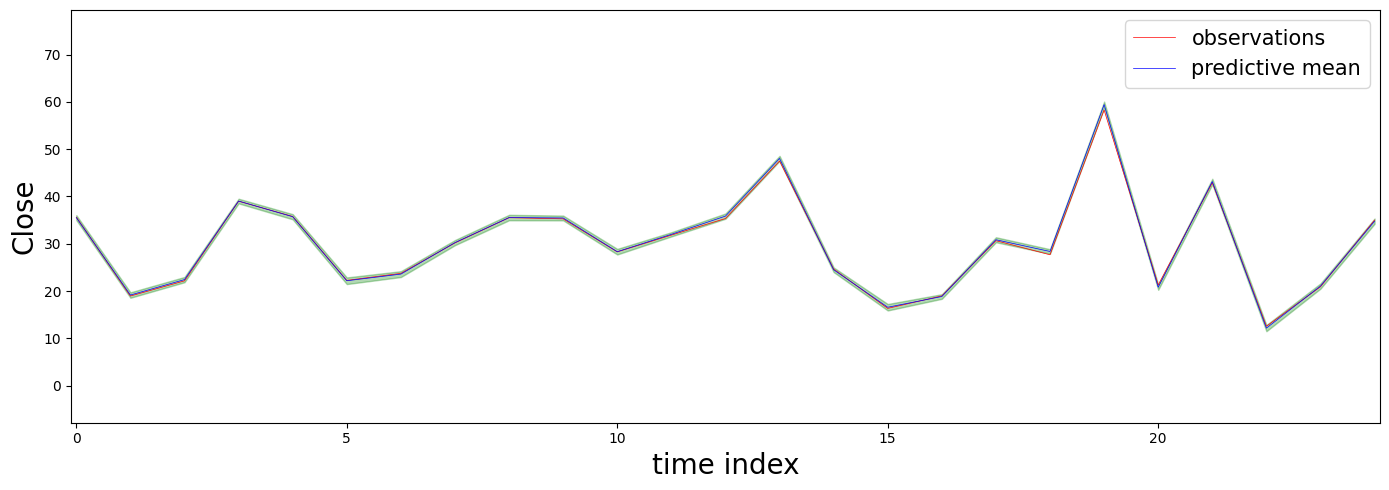

In [8]:
predictive = Predictive(model=model_HMC, posterior_samples=mcmc.get_samples())
preds_HMC = predictive(x_test)
sliced_plot_predictions(preds_HMC, np.array(range(len(y_test))), y_test, 25)

### 4. Variational Inference (VI)

HMC lacks scalability. Empirically speaking, if the number of parameters in BNN is increased (for example, increase the hid_dim of instance of class one_hidden_layer_BNN), the running time of HMC will increase drastically (for example, the first block in above section 3).

So we consider VI, a more scalable algorithm to sample from the posterior distribution of parameters. The key idea of VI is: rather than sampling from the exact posterior, sampling from a variational distribution $q_{\phi}(\theta)$ parameterized by $\phi$, which approximated the exact posterier. Popular choice of $q_{\phi}(\theta)$ can be multi-variate Gaussian. The covariance matrix can be set to be diagonal to reduce number of parameters.

The difference between variational distribution $q_{\phi}(\theta)$ and exact posterier $P(\theta | D)$ can be measured using KL divergence, and the goal is to minimize KL divergence: $\min_{\phi}\mathbb{D}_{KL}(q_{\phi} \rVert P) = \int q_{\phi}(\theta')\log\frac{q_{\phi}(\theta')}{P(\theta' | D)}d\theta'$.

Since the $P(\theta' | D)$ is the above objective function is intractable, we need to rewrite the objective function. Based on:

$\log P(D) = \log\int P(\theta', D)d\theta' = \log\int P(\theta', D)\frac{q_{\phi}(\theta')}{q_{\phi}(\theta')}d\theta' \leq \int q_{\phi}(\theta')\log\frac{P(\theta', D)}{q_{\phi}(\theta')} d\theta'$.

$\int q_{\phi}(\theta')\log\frac{P(\theta', D)}{q_{\phi}(\theta')} d\theta' = \int q_{\phi}(\theta')\log\frac{P(\theta' | D)}{q_{\phi}(\theta')} d\theta' + (\log P(D))\int q_{\phi}(\theta')d\theta' = \log P(D) - \mathbb{D}_{KL}(q_{\phi} \rVert P)$.

The original optimization problem can be equivalently converted to: $\max_{\phi}\int q_{\phi}(\theta')\log\frac{P(\theta', D)}{q_{\phi}(\theta')} d\theta'$. And it can be intepreted as maximizing the upper bound of log likelihood. SVI algorithm can be used to solve this optimization problem, which applies stochastic gradient descent to variational inference.

In [41]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange
pyro.clear_param_store()

In [42]:
model_VI = one_hidden_layer_BNN(in_dim=3, hid_dim=128, prior_scale=2) # larger hidden dimension compared to model_HMC

mean_field_guide = AutoMultivariateNormal(model_VI) # set variational distribution as multi-variate Gaussian with general covariance
optimizer = pyro.optim.Adam({"lr": 0.001})

In [43]:
svi = SVI(model_VI, mean_field_guide, optimizer, loss=Trace_ELBO()) # apply stochastic gradient descent to variational inference
pyro.clear_param_store()

num_epochs = 25000
progress_bar = trange(num_epochs)

In [44]:
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

Warmup:   0%|          | 0/100 [01:58, ?it/s]


ValueError: Expected parameter loc (Tensor of shape (992,)) of distribution Normal(loc: torch.Size([992]), scale: torch.Size([992])) to satisfy the constraint Real(), but found invalid values:
tensor([ 4.5030e-01,  4.0220e-01, -1.6411e-01, -1.8029e-01,         nan,
         7.2334e-01, -1.8026e-01,  7.8232e-01, -2.4705e-01,  1.3570e+00,
         1.2986e-02, -1.8079e-01, -8.3647e-02,  1.0167e+00,  6.1657e-01,
         1.1778e-01, -1.7476e-01, -3.1225e-01,  6.3262e-01,  4.0761e-01,
         5.5840e-01, -1.8883e-01,  5.9439e-01,  7.0006e-01, -2.4129e-01,
        -3.1975e-01,  1.4239e-01, -1.6754e-01,  2.5912e-01, -2.2710e-01,
        -2.8788e-01,  6.1444e-02, -1.6833e-01,  3.9914e-01,  3.5139e+00,
        -2.5463e-01, -9.5736e-02,  1.0751e+00,  5.2885e-01,  6.3357e-02,
        -3.4465e-01,  1.0658e-01, -9.6524e-04, -5.5547e-02, -1.7705e-01,
         6.6952e-01, -2.6890e-01,  1.2945e+00,  7.0194e-01, -2.6573e-01,
         7.0333e-01, -2.6305e-01, -2.6166e-01, -1.8549e-01, -2.1923e-01,
    

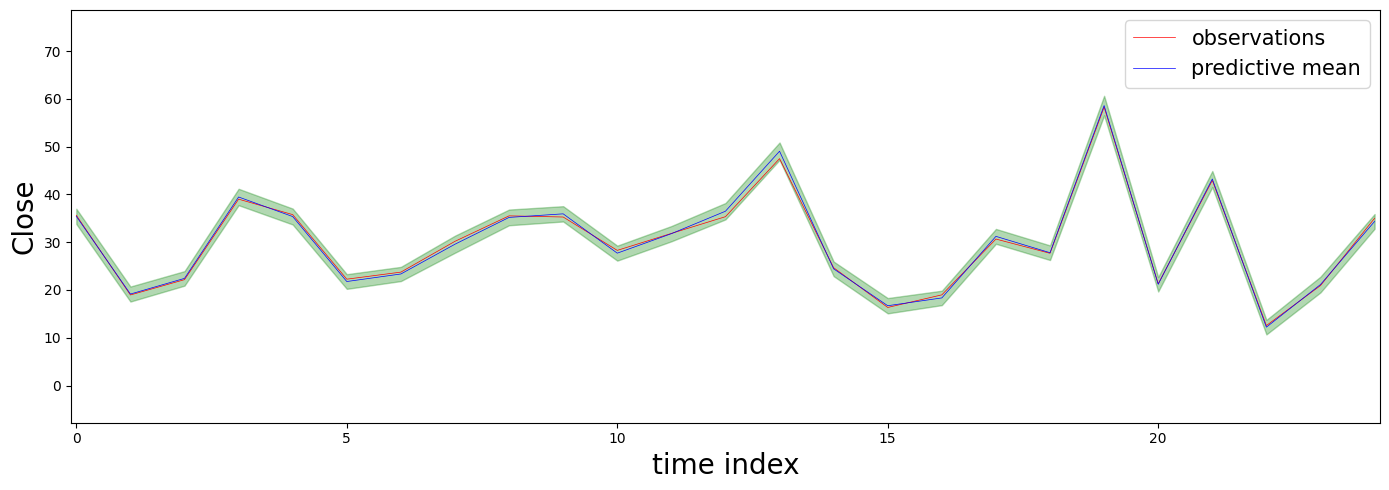

In [13]:
predictive = Predictive(model_VI, guide=mean_field_guide, num_samples=500)
preds = predictive(x_test)
sliced_plot_predictions(preds, np.array(range(len(y_test))), y_test, 25)